# 07 — Heterogeneous treatment effects

**Purpose.** Find out whether the average effects hide meaningful variation between
customers — and specifically, whether anyone is made *worse* by being emailed.

Everything so far reports averages. An average is compatible with a great deal of
disagreement underneath it: a campaign lifting visits by 7.7 points on average could
be lifting one group by 15 points while driving another away. Features 8 to 10 propose
to target customers individually, which is only worth doing if that variation exists.
This notebook establishes whether it does.

### Two commitments made before looking

**Subgroups are pre-registered.** The list lives in `config.PREREGISTERED_SUBGROUPS`
with a rationale for each, fixed before any subgroup effect was estimated. Splitting
the data every possible way and reporting the strongest split is how subgroup analysis
earned its reputation; committing in advance, in version control, is the defence.

**Heterogeneity is tested by interaction, not by comparing subgroup p-values.** This
is the single most common error in applied subgroup analysis and section 1 demonstrates
it explicitly.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

from src import config
from src.data.load import load_processed
from src.analysis.heterogeneity import (
    run_heterogeneity_analysis, subgroup_effects, interaction_test,
)

pd.set_option("display.width", 150)
df = load_processed()

print("Pre-registered subgroups:")
for name, rationale in config.PREREGISTERED_SUBGROUPS.items():
    print(f"  {name:<16} {rationale}")
print("\nExploratory (reported, but not part of the corrected family):")
for name, rationale in config.EXPLORATORY_SUBGROUPS.items():
    print(f"  {name:<16} {rationale}")

Pre-registered subgroups:
  mens             Prior mens purchasers should respond more to the Mens campaign
  womens           Prior womens purchasers should respond more to the Womens campaign
  recency_bucket   Recent purchasers are more engaged, so likely more responsive
  newbie           New and established customers may respond differently
  channel          Prior purchase channel may moderate responsiveness to email

Exploratory (reported, but not part of the corrected family):
  history_segment  Spend band may moderate response
  zip_code         Location may moderate response


## 1. Why per-subgroup p-values do not answer the question

The tempting reading of a subgroup table is: "significant among new customers, not
significant among established ones — therefore the effect differs between them."

That inference is invalid. Two estimates can fall on opposite sides of a significance
threshold while being statistically indistinguishable *from each other*. Significance
compares each estimate to zero; the question being asked compares them to one another.

Here is a synthetic experiment built with **exactly equal** effects in both subgroups.

In [2]:
rng = np.random.default_rng(3)
n = 60_000
group = rng.random(n) < 0.5
treated = rng.random(n) < 0.5
demo = pd.DataFrame({
    "visit": rng.binomial(1, np.clip(0.10 + treated * 0.10, 0, 1)),
    "newbie": group.astype(int),
    "treated": treated.astype(int),
    config.TREATMENT_COL: pd.Categorical(
        np.where(treated, config.MENS_ARM, config.CONTROL_ARM),
        categories=[config.CONTROL_ARM, config.MENS_ARM, config.WOMENS_ARM]),
})

levels = subgroup_effects(demo, "visit", config.MENS_ARM, "newbie")
print("Effects by subgroup (true effect is 0.10 in BOTH):")
print(levels[["level", "effect", "ci_low", "ci_high", "p_value"]].to_string(index=False))

result = interaction_test(demo, "visit", config.MENS_ARM, "newbie")
print(f"\nBoth subgroups significant (p < 1e-30).")
print(f"Interaction test: F = {result.f_statistic:.3f}, p = {result.p_value:.3f}")
print("-> correctly reports no difference between them.")

Effects by subgroup (true effect is 0.10 in BOTH):
               level   effect   ci_low  ci_high       p_value
Established customer 0.100822 0.092799 0.108846 4.744722e-131
        New customer 0.101828 0.093783 0.109872 7.973251e-134

Both subgroups significant (p < 1e-30).
Interaction test: F = 0.030, p = 0.862
-> correctly reports no difference between them.


Both subgroups return overwhelming significance, and the interaction test correctly
finds nothing. The converse case is equally common and equally misleading: a small
effect that clears α and a slightly smaller one that does not are easily
indistinguishable. The test suite asserts both cases.

### Interactions are expensive

Two factors compound. An interaction is a difference of two differences, so it carries
the variance of both — a factor of √2. And each difference is estimated on half the
customers — another √2. The standard error is therefore about **twice** that of the
main effect, so detecting an interaction of a given size needs roughly **four times**
the customers.

In [3]:
main_only = smf.ols("visit ~ treated", data=demo).fit(cov_type="HC3")
interacted = smf.ols("visit ~ treated * C(newbie)", data=demo).fit(cov_type="HC3")
term = [i for i in interacted.params.index if "treated:" in i][0]

print(f"SE of main effect (full sample)   : {main_only.bse['treated']:.6f}")
print(f"SE of interaction term            : {interacted.bse[term]:.6f}")
print(f"Ratio                             : "
      f"{interacted.bse[term] / main_only.bse['treated']:.2f}x  -> ~4x the sample needed")

SE of main effect (full sample)   : 0.002898
SE of interaction term            : 0.005797
Ratio                             : 2.00x  -> ~4x the sample needed


Feature 5 already found that only `visit` has power to spare — conversion and spend
could barely detect their own main effects. Multiplying their requirements by four
makes subgroup analysis on those outcomes hopeless.

**So `visit` carries the primary analysis.** Conversion and spend are computed and
reported, but treated as underpowered rather than quietly presented as equals.

## 2. Interaction tests

In [4]:
results = run_heterogeneity_analysis(df, save=False)
interactions, effects = results["interactions"], results["effects"]

primary = interactions[
    (interactions["outcome"] == config.HETEROGENEITY_PRIMARY_OUTCOME)
    & interactions["preregistered"]
]
primary[[
    "treatment_arm", "subgroup", "levels", "f_statistic",
    "p_value", "p_value_adjusted", "significant",
]].style.format({
    "f_statistic": "{:.3f}", "p_value": "{:.4f}", "p_value_adjusted": "{:.4f}",
}).hide(axis="index")

treatment_arm,subgroup,levels,f_statistic,p_value,p_value_adjusted,significant
Mens E-Mail,mens,2,2.644,0.1039,0.2217,False
Mens E-Mail,womens,2,3.921,0.0477,0.1590,False
Mens E-Mail,recency_bucket,4,1.159,0.3236,0.5394,False
Mens E-Mail,newbie,2,0.140,0.7082,0.8853,False
Mens E-Mail,channel,3,0.224,0.7990,0.8878,False
Womens E-Mail,mens,2,64.418,0.0000,0.0000,True
Womens E-Mail,womens,2,94.204,0.0000,0.0000,True
Womens E-Mail,recency_bucket,4,0.790,0.4990,0.7129,False
Womens E-Mail,newbie,2,2.542,0.1109,0.2217,False
Womens E-Mail,channel,3,0.030,0.9705,0.9705,False


**A sharp asymmetry between the two campaigns.**

The **Womens E-Mail** shows overwhelming heterogeneity by purchase history — F = 94 on
prior womens purchases, F = 64 on prior mens purchases, both surviving
Benjamini-Hochberg correction with room to spare.

The **Mens E-Mail** shows none. Not one pre-registered subgroup moderates it. The
closest is prior womens purchase at raw p = 0.048, which does not survive correction —
and given five tests, one result near 0.05 is what chance produces.

Benjamini-Hochberg rather than Holm here, deliberately. Subgroup analysis is a
**screen**: its job is to produce a shortlist worth modelling in Feature 8, not claims
to act on directly. Controlling the false discovery rate suits a screen; controlling
family-wise error would discard signal the uplift models could have used.

## 3. What the Womens heterogeneity looks like

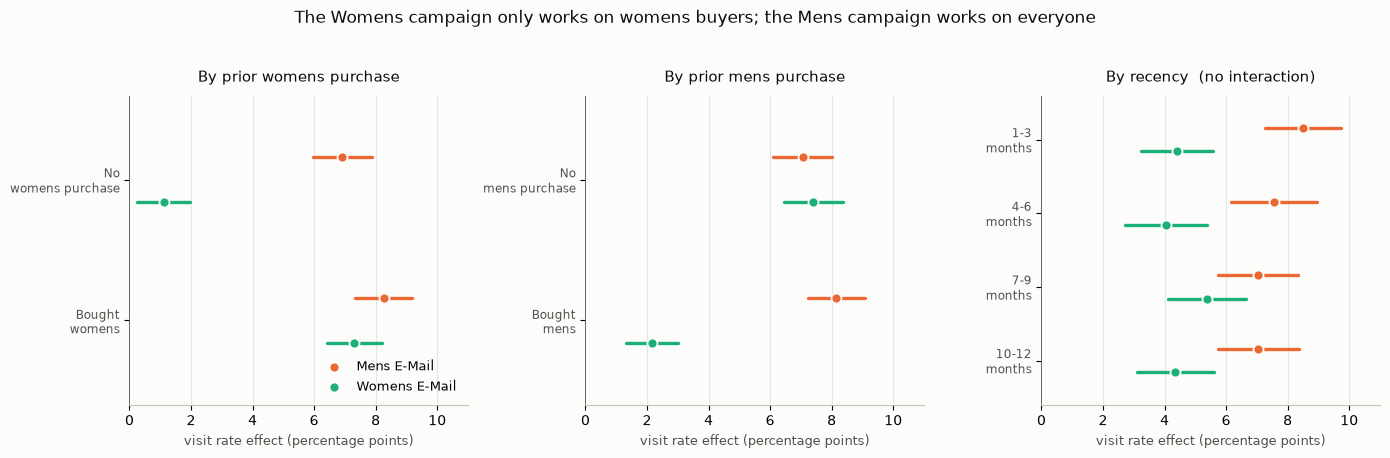

In [5]:
ARM_COLOURS = {"Mens E-Mail": "#eb6834", "Womens E-Mail": "#1baf7a"}
PANELS = ["womens", "mens", "recency_bucket"]
TITLES = {
    "womens": "By prior womens purchase",
    "mens": "By prior mens purchase",
    "recency_bucket": "By recency  (no interaction)",
}

visit_effects = effects[effects["outcome"] == "visit"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.4))
fig.patch.set_facecolor("#fcfcfb")

for ax, subgroup in zip(axes, PANELS):
    subset = visit_effects[visit_effects["subgroup"] == subgroup]

    # Ordered categoricals carry their own order; alphabetical sorting would
    # put "10-12 months" between "1-3" and "4-6".
    present = set(subset["level"].unique())
    if isinstance(df[subgroup].dtype, pd.CategoricalDtype):
        order = [l for l in df[subgroup].cat.categories if l in present][::-1]
    else:
        order = sorted(present)
    positions = {level: i for i, level in enumerate(order)}

    for arm, colour in ARM_COLOURS.items():
        arm_rows = subset[subset["treatment_arm"] == arm]
        for _, row in arm_rows.iterrows():
            y = positions[row["level"]] + (0.16 if arm == "Mens E-Mail" else -0.16)
            ax.plot([row["ci_low"] * 100, row["ci_high"] * 100], [y, y],
                    color=colour, linewidth=2.4, zorder=3, solid_capstyle="round")
            ax.scatter([row["effect"] * 100], [y], s=52, color=colour, zorder=4,
                       edgecolor="#fcfcfb", linewidth=1.3,
                       label=arm if row["level"] == order[0] else None)

    ax.axvline(0, color="#52514e", linewidth=1.2, zorder=2)
    ax.set_facecolor("#fcfcfb")
    ax.set_yticks(range(len(order)))
    ax.set_yticklabels([str(l).replace(" ", "\n", 1) for l in order],
                       fontsize=8.5, color="#52514e")
    ax.set_ylim(-0.6, len(order) - 0.4)
    ax.set_xlim(0, 11)
    ax.set_title(TITLES[subgroup], fontsize=11, color="#0b0b0b", pad=10)
    ax.set_xlabel("visit rate effect (percentage points)", fontsize=9, color="#52514e")
    ax.grid(axis="x", color="#e6e5e1", linewidth=0.8, zorder=0)
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color("#c3c2b7")

axes[0].legend(frameon=False, fontsize=9, loc="lower right")
fig.suptitle(
    "The Womens campaign only works on womens buyers; the Mens campaign works on everyone",
    fontsize=12, color="#0b0b0b", y=1.03,
)
fig.tight_layout()

FIG_DIR = PROJECT_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIG_DIR / "07_heterogeneous_effects.png", dpi=150,
            bbox_inches="tight", facecolor="#fcfcfb")
plt.show()

In [6]:
focus = visit_effects[
    (visit_effects["treatment_arm"] == config.WOMENS_ARM)
    & (visit_effects["subgroup"].isin(["womens", "mens"]))
]
focus[[
    "subgroup", "level", "n_treated", "control_mean",
    "effect", "ci_low", "ci_high", "relative_effect",
]].style.format({
    "n_treated": "{:,}", "control_mean": "{:.4f}",
    "effect": "{:+.4f}", "ci_low": "{:+.4f}", "ci_high": "{:+.4f}",
    "relative_effect": "{:+.1%}",
}).hide(axis="index")

subgroup,level,n_treated,control_mean,effect,ci_low,ci_high,relative_effect
mens,Bought mens,"11,740",0.1145,+0.0218,+0.0133,+0.0302,+19.0%
mens,No mens purchase,"9,647",0.0958,+0.0740,+0.0644,+0.0835,+77.2%
womens,Bought womens,"11,765",0.1114,+0.0731,+0.0641,+0.0822,+65.6%
womens,No womens purchase,"9,622",0.0998,+0.0111,+0.0024,+0.0197,+11.1%


The Womens campaign lifts visits by **7.31 points** among customers who previously
bought womens merchandise, and **1.11 points** among those who did not — a **6.6x**
difference, with non-overlapping intervals.

### The two significant subgroups are one finding, not two

Prior *mens* purchase also moderates the Womens campaign, and in the opposite
direction: +2.18 points for mens buyers versus +7.40 for non-mens buyers. That looks
like a second discovery but is mostly the same one seen from behind. Every customer in
this dataset has bought something, so "no mens purchase" largely means "womens-only
buyer" — the group that responds most strongly to a womens campaign.

Reporting these as two independent findings would double-count a single effect. The
underlying variable is simply whether the customer buys womens merchandise.

### The Mens campaign is uniform, and that is also a result

Its effect sits between 7.1 and 8.2 points in every subgroup examined. That is worth
stating plainly because it bounds what Feature 9 can achieve: **there is little for a
targeting model to exploit on the Mens campaign.** Any gain from personalisation will
come from deciding who receives the *Womens* campaign, and from choosing between the
two.

## 4. Is anyone actively harmed?

The question that matters most for targeting. If some segment is driven away by email,
Feature 9 should exclude them, and the profit case in Feature 10 changes shape.

In [7]:
harmful = effects[effects["harmful"]]
negative = effects[effects["effect"] < 0]

print(f"Level estimates computed        : {len(effects)}")
print(f"Negative at the point estimate  : {len(negative)}")
print(f"Intervals entirely below zero   : {len(harmful)}")
print()
if len(negative):
    print("The negative point estimates, all with intervals spanning zero:\n")
    print(negative[[
        "treatment_arm", "outcome", "subgroup", "level",
        "n_treated", "effect", "ci_low", "ci_high",
    ]].to_string(index=False))

Level estimates computed        : 132
Negative at the point estimate  : 4
Intervals entirely below zero   : 0

The negative point estimates, all with intervals spanning zero:

treatment_arm    outcome        subgroup          level  n_treated    effect    ci_low  ci_high
Womens E-Mail conversion history_segment 3) $200 - $350       4155 -0.000666 -0.004171 0.002838
Womens E-Mail conversion history_segment 4) $350 - $500       2188 -0.002159 -0.008168 0.003850
Womens E-Mail      spend history_segment 3) $200 - $350       4155 -0.323141 -0.890789 0.244507
Womens E-Mail      spend history_segment 4) $350 - $500       2188 -0.100890 -0.868422 0.666642


**No subgroup is measurably harmed.** Four of 132 level estimates are negative, all
on the underpowered conversion and spend outcomes, all in mid-range spend bands, and
every one has an interval comfortably spanning zero. Four negatives out of 132
estimates is fewer than chance alone would produce.

Two honest caveats on that conclusion:

1. **Absence of evidence at this resolution.** These are effects averaged over
   subgroups of thousands. A genuinely harmed segment defined by a *combination* of
   attributes — say recent, high-spending, phone-channel customers — would be invisible
   here. Finding that is precisely what the individual-level uplift models in Feature 8
   are for.
2. **The negative estimates carry no weight.** They sit on the two outcomes Feature 5
   showed were barely powered for their own main effects, let alone subgroup splits.

## 5. Exploratory subgroups

Reported separately and excluded from the corrected family, because they were not
pre-registered. Anything here is a hypothesis for a future experiment, not a finding.

In [8]:
exploratory = interactions[
    (interactions["outcome"] == "visit") & (~interactions["preregistered"])
]
exploratory[[
    "treatment_arm", "subgroup", "levels", "f_statistic", "p_value",
]].style.format({"f_statistic": "{:.3f}", "p_value": "{:.4f}"}).hide(axis="index")

treatment_arm,subgroup,levels,f_statistic,p_value
Mens E-Mail,history_segment,7,1.587,0.1463
Mens E-Mail,zip_code,3,0.327,0.7208
Womens E-Mail,history_segment,7,0.851,0.5303
Womens E-Mail,zip_code,3,1.815,0.1629


`history_segment` shows the widest raw spread of any subgroup — Mens E-Mail effects
range from 6.2 to 9.9 points across spend bands. It was not pre-registered, it is one
of seven levels tested twice, and its interaction p-value is not compelling. It is
noted as a candidate hypothesis and nothing more.

## Conclusions

| Question | Answer |
|---|---|
| Does the Mens campaign vary by customer? | No — 7.1 to 8.2 points everywhere |
| Does the Womens campaign vary? | Strongly — 1.1 to 7.3 points by purchase history |
| Is anyone actively harmed? | Not detectably at subgroup resolution |
| Where is the targeting opportunity? | Choosing *who gets the Womens campaign*, and choosing *between* campaigns |

The practical implication is specific and it constrains what follows. Personalisation
has real headroom on the Womens campaign, where the effect varies by a factor of six,
and very little on the Mens campaign, which works about equally well on everyone. A
targeting policy that reassigns weak Womens recipients to the Mens campaign is the
obvious candidate — and quantifying that is exactly what Features 8 and 9 do.

**Next — Feature 8:** uplift models, which estimate the treatment effect for each
individual customer rather than for pre-defined groups, and can find the combinations
of attributes this analysis is too coarse to see.